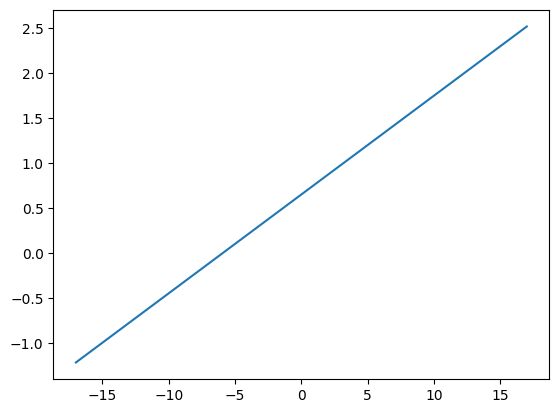

In [55]:
from QSM.solver import find_trim_angle,calculate_kite_speed
from QSM.forces import calculate_tether_force, calculate_tangential_force
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

mass = 581.56
wing_area = 15

#Given parameters
Cl_maxAirfoil = 2.5 #Maximum lift coefficient
Cl0_airfoil   = 0.65 #Lift coefficient at zero angle of attack
e             = 0.6 #Oswald efficiency factor
Cd0           = 0.056 #Parasitic drag coefficient
AR            = 12 #Aspect ratio of the wing, assumed value
dCl_dalpha    = 2 * np.pi #Slope of CL-alpha curve in rad^-1
 
#Define range of alpha in degrees and convert to radians
alpha_deg = np.linspace(-17, 17, 35)
alpha_rad = np.deg2rad(alpha_deg)
 
#Calculate CL for each alpha
cl_curve= Cl0_airfoil + dCl_dalpha * alpha_rad
 
#Calculate CD for each CL
cd_curve = Cd0 + ((cl_curve - Cl0_airfoil)**2) / (np.pi * AR * e)


alpha_curve = alpha_rad


plt.plot(alpha_deg, cl_curve, label='CL')
# plt.plot(alpha_deg, cd_curve, label='CD')

In [56]:
# Solve Lloyd condition and trim angle of attack
alpha_trim_kite = find_trim_angle(alpha_curve, cl_curve, cd_curve)
CL_trim = np.interp(alpha_trim_kite, alpha_curve, cl_curve)
CD_trim = np.interp(alpha_trim_kite, alpha_curve, cd_curve)
print(f'Trim angle of attack: {np.degrees(alpha_trim_kite)} deg')
print(f'Trim lift coefficient: {CL_trim}')
print(f'Trim drag coefficient: {CD_trim}')



Trim angle of attack: [3.59127874] deg
Trim lift coefficient: [1.04382778]
Trim drag coefficient: [0.06298542]


Alpha trim: [3.59127874] deg
Kite speed: [-115.7800865] m/s
Tether force: [124525.57076979] N


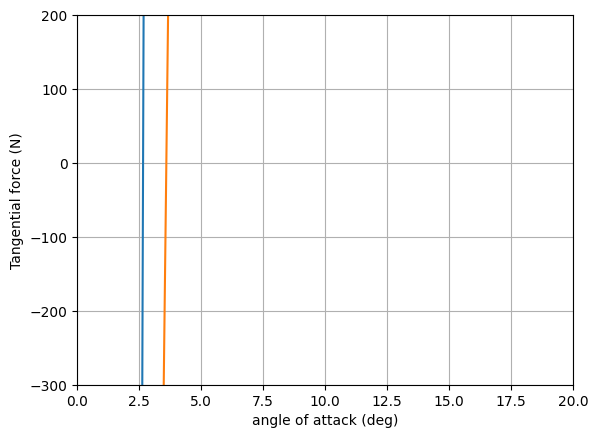

In [57]:
import matplotlib.pyplot as plt

azimuth = -10
elevation = np.radians(30)
headings = np.radians(np.linspace(-90, 90, 3))
reelout_speed = 0
wind_speed = 10

plt.figure()
for heading in headings:
    # Calculate the tangential force
    ftan = calculate_tangential_force(alpha_curve,cl_curve,cd_curve,azimuth, elevation, reelout_speed, wind_speed, wing_area, mass = mass, heading = heading)
    plt.plot(np.degrees(alpha_curve), ftan, label=f'Wind speed = {wind_speed} m/s')

plt.xlabel('angle of attack (deg)')
plt.ylabel('Tangential force (N)')
plt.grid()
plt.ylim(-300,200)
plt.xlim(0,20)

alpha_trim = alpha_trim_kite
kite_speed = calculate_kite_speed(alpha_trim,azimuth, elevation, reelout_speed, wind_speed, heading)
tether_force = calculate_tether_force(alpha_trim,CL_trim,CD_trim,azimuth, elevation, reelout_speed, wind_speed,kite_speed, wing_area, mass = mass, heading = heading)

print(f'Alpha trim: {np.degrees(alpha_trim)} deg')
print(f'Kite speed: {kite_speed} m/s')
print(f'Tether force: {tether_force} N')

In [58]:
# Solve specific condition with weight
azimuth = np.radians(6)
elevation = np.radians(15.2)
heading = np.radians(0)

wind_speed = 8.7
reelout_speed = 2.14

alpha_trim = find_trim_angle(alpha_curve, 
                            cl_curve,
                            cd_curve,
                            wind_speed=wind_speed,
                            reelout_speed=reelout_speed,
                            azimuth=azimuth,
                            elevation=elevation,
                            mass=mass,
                            wing_area=wing_area,
                            heading=heading)
CL_trim = np.interp(alpha_trim, alpha_curve, cl_curve)
CD_trim = np.interp(alpha_trim, alpha_curve, cd_curve)

alpha_trim = np.radians(14)
kite_speed = calculate_kite_speed(alpha_trim,azimuth, elevation, reelout_speed, wind_speed, heading)
tether_force = calculate_tether_force(alpha_trim,CL_trim,CD_trim,azimuth, elevation, reelout_speed, wind_speed,kite_speed, wing_area, mass = mass, heading = heading)

power = tether_force * reelout_speed

print(f'Alpha trim: {np.degrees(alpha_trim)} deg')
print(f'Kite speed: {kite_speed} m/s')
print(f'Tether force: {tether_force} N')
print(f'Power: {power} W')




Alpha trim: 14.0 deg
Kite speed: 25.814948621669014 m/s
Tether force: [6271.60480261] N
Power: [13421.23427759] W


: 

Trim angle of attack: [6.04001436] deg


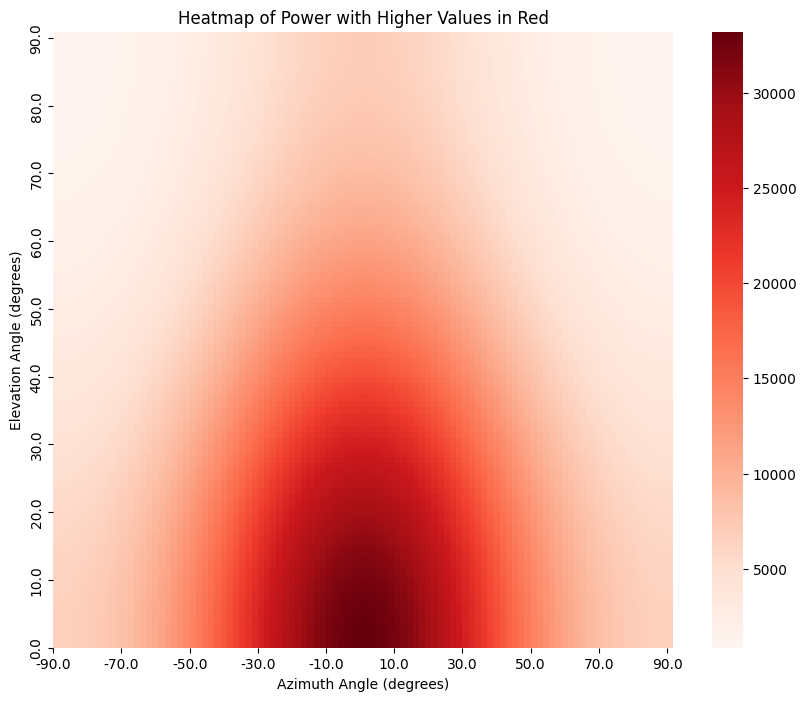

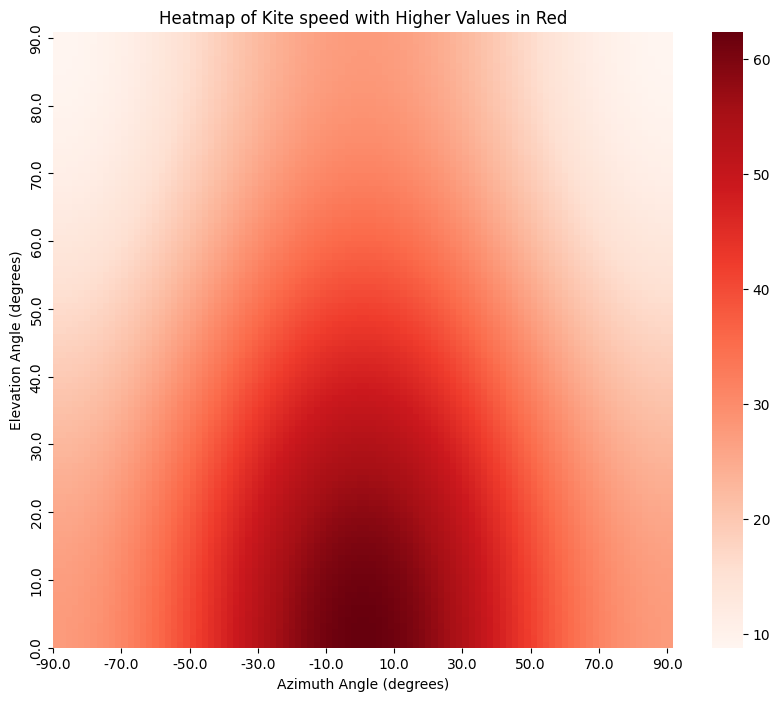

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
## Plot wind window for 0 yaw angle
wind_speed = 8
reelout_speed = 1.4


# Elevation and azimuth angles in radians
elevation_angle = np.linspace(0, 90, 100) * np.pi / 180
azimuth_angle = np.linspace(-90, 90, 100) * np.pi / 180

# Create meshgrid for elevation and azimuth angles
azimuth_grid, elevation_grid = np.meshgrid(azimuth_angle,elevation_angle)

alpha_trim_kite = find_trim_angle(alpha_curve, cl_curve, cd_curve)
print(f'Trim angle of attack: {np.degrees(alpha_trim_kite)} deg')
CL_trim = np.interp(alpha_trim_kite, alpha_curve, cl_curve)
CD_trim = np.interp(alpha_trim_kite, alpha_curve, cd_curve)

kite_speed = calculate_kite_speed(alpha_trim_kite,azimuth_grid, elevation_grid, reelout_speed, wind_speed, heading)
tether_force = calculate_tether_force(alpha_trim_kite,CL_trim,CD_trim,azimuth_grid, elevation_grid, reelout_speed, wind_speed,kite_speed, wing_area, mass = mass, heading = heading)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(tether_force,cmap="Reds")
# Set the number of ticks
num_ticks = 10
plt.xticks(ticks=np.linspace(0, len(np.sin(azimuth_angle)) - 1, num_ticks), 
           labels=np.round(np.linspace(-90, 90, num_ticks), 1))
plt.yticks(ticks=np.linspace(0, len(np.sin(elevation_angle)) - 1, num_ticks), 
           labels=np.round(np.linspace(0, 90, num_ticks), 1))
# Invert the y-axis
plt.gca().invert_yaxis()

# Customize the plot
plt.title('Heatmap of Power with Higher Values in Red')
plt.xlabel('Azimuth Angle (degrees)')
plt.ylabel('Elevation Angle (degrees)')
plt.show()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(kite_speed,cmap="Reds")
# Set the number of ticks
num_ticks = 10
plt.xticks(ticks=np.linspace(0, len(np.sin(azimuth_angle)) - 1, num_ticks), 
           labels=np.round(np.linspace(-90, 90, num_ticks), 1))
plt.yticks(ticks=np.linspace(0, len(np.sin(elevation_angle)) - 1, num_ticks), 
           labels=np.round(np.linspace(0, 90, num_ticks), 1))
# Invert the y-axis
plt.gca().invert_yaxis()

# Customize the plot
plt.title('Heatmap of Kite speed with Higher Values in Red')
plt.xlabel('Azimuth Angle (degrees)')
plt.ylabel('Elevation Angle (degrees)')
plt.show()
